# Task 1 — Data Exploration and Assumption Checks

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import shapiro, levene, mannwhitneyu, chi2_contingency, pearsonr
from statsmodels.stats.power import TTestIndPower

sns.set_style("whitegrid")


## 1.1 Load and Inspect the Dataset

In [2]:
df = pd.read_csv("netflix1.csv")

print("Shape:", df.shape)
print()
print(df.dtypes)
print()
print("Missing values:")
print(df.isnull().sum())
print()
df.head()


Shape: (8790, 10)

show_id           str
type              str
title             str
director          str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
dtype: object

Missing values:
show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64



,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


## 1.2 Feature Engineering

The `duration` column contains mixed units — minutes for movies and seasons for TV shows. These cannot be compared directly, so I create separate numeric columns and will analyse movies and TV shows independently where duration is involved.


In [3]:
# Extract numeric duration
df['duration_int'] = df['duration'].str.extract(r'(\d+)').astype(float)

# Separate datasets
movies = df[df['type'] == 'Movie'].copy()
tv_shows = df[df['type'] == 'TV Show'].copy()

print(f"Movies: {len(movies)}, TV Shows: {len(tv_shows)}")
print(f"Movie duration (min): mean={movies['duration_int'].mean():.1f}, std={movies['duration_int'].std():.1f}")
print(f"TV Show duration (seasons): mean={tv_shows['duration_int'].mean():.1f}, std={tv_shows['duration_int'].std():.1f}")


Movies: 6126, TV Shows: 2664
Movie duration (min): mean=99.6, std=28.3
TV Show duration (seasons): mean=1.8, std=1.6


## 1.3 Distribution Visualizations

/var/folders/ls/rx_sxrx11sz9qcnsbtj3t5x00000gn/T/ipykernel_1539/2499316809.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='rating', order=df['rating'].value_counts().index, ax=axes[2], palette='viridis')


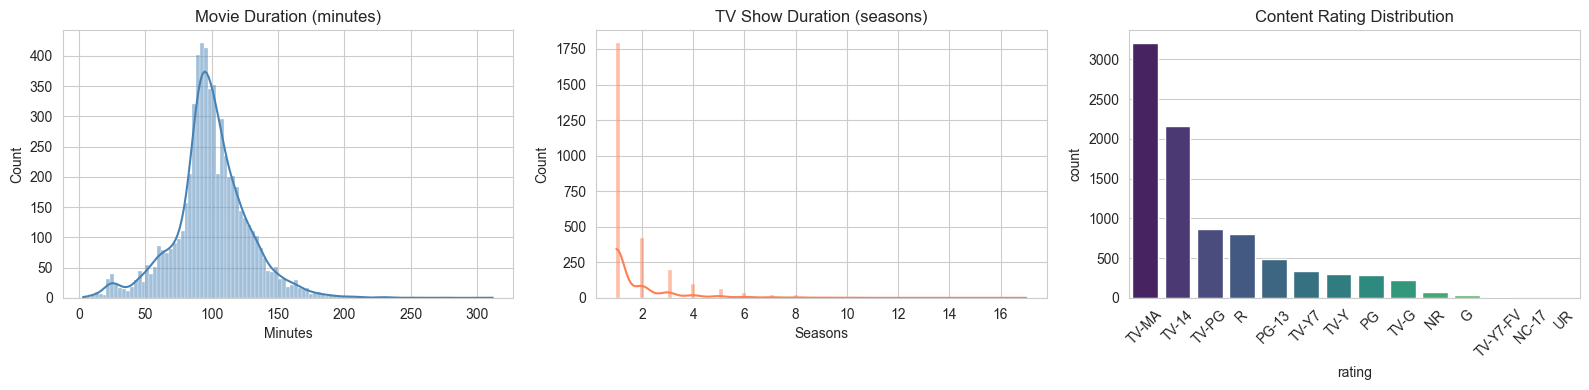

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(movies['duration_int'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title("Movie Duration (minutes)")
axes[0].set_xlabel("Minutes")

sns.histplot(tv_shows['duration_int'], kde=True, ax=axes[1], color='coral')
axes[1].set_title("TV Show Duration (seasons)")
axes[1].set_xlabel("Seasons")

sns.countplot(data=df, x='rating', order=df['rating'].value_counts().index, ax=axes[2], palette='viridis')
axes[2].set_title("Content Rating Distribution")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


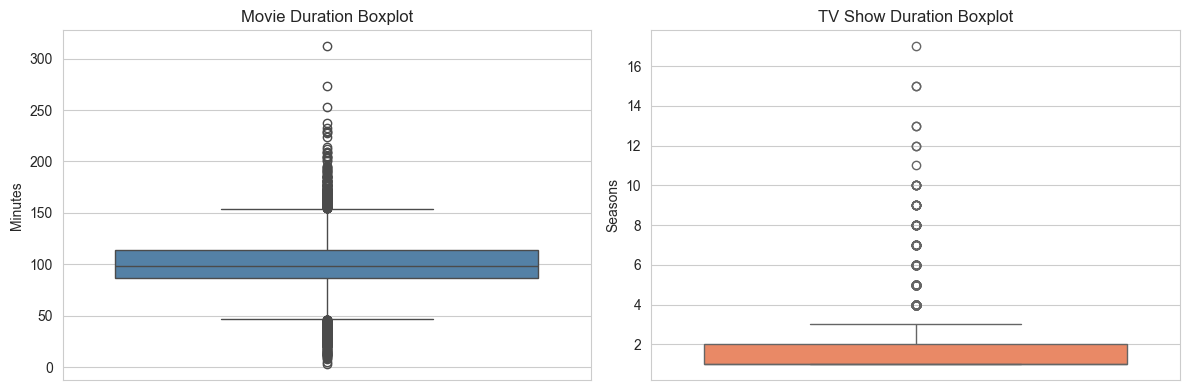

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=movies, y='duration_int', ax=axes[0], color='steelblue')
axes[0].set_title("Movie Duration Boxplot")
axes[0].set_ylabel("Minutes")

sns.boxplot(data=tv_shows, y='duration_int', ax=axes[1], color='coral')
axes[1].set_title("TV Show Duration Boxplot")
axes[1].set_ylabel("Seasons")

plt.tight_layout()
plt.show()


## 1.4 Normality Checks

In [6]:
# Shapiro-Wilk test (sample of 500 due to test size limits)
sample_movies = movies['duration_int'].dropna().sample(500, random_state=42)
stat_m, p_m = shapiro(sample_movies)
print(f"Shapiro-Wilk for movie duration: stat={stat_m:.4f}, p={p_m:.6f}")

sample_tv = tv_shows['duration_int'].dropna().sample(min(500, len(tv_shows)), random_state=42)
stat_t, p_t = shapiro(sample_tv)
print(f"Shapiro-Wilk for TV show duration: stat={stat_t:.4f}, p={p_t:.6f}")


Shapiro-Wilk for movie duration: stat=0.9671, p=0.000000
Shapiro-Wilk for TV show duration: stat=0.5314, p=0.000000


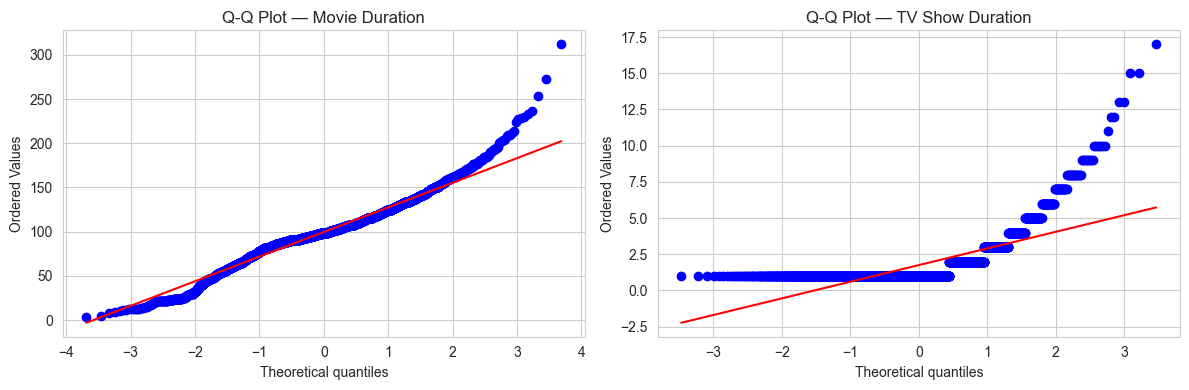

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

stats.probplot(movies['duration_int'].dropna(), dist="norm", plot=axes[0])
axes[0].set_title("Q-Q Plot — Movie Duration")

stats.probplot(tv_shows['duration_int'].dropna(), dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot — TV Show Duration")

plt.tight_layout()
plt.show()


### Normality Results

Both Shapiro-Wilk tests return p < 0.05, meaning we reject the null hypothesis of normality for both movie durations and TV show season counts. The Q-Q plots confirm this: movie durations show right-skew with heavy tails, and TV show seasons are strongly right-skewed (most shows have 1–2 seasons).

These violations mean parametric tests that assume normality (e.g., independent t-test) may not be reliable. Non-parametric alternatives should be preferred.


## 1.5 Equal Variance Check

In [8]:
# For comparing movie durations across rating groups (will be used in Task 2)
# Pick the two largest rating groups for movies
top2_ratings = movies['rating'].value_counts().index[:2]
group1 = movies[movies['rating'] == top2_ratings[0]]['duration_int'].dropna()
group2 = movies[movies['rating'] == top2_ratings[1]]['duration_int'].dropna()

stat_lev, p_lev = levene(group1, group2)
print(f"Levene's test ({top2_ratings[0]} vs {top2_ratings[1]}): stat={stat_lev:.4f}, p={p_lev:.6f}")


Levene's test (TV-MA vs TV-14): stat=88.0110, p=0.000000


### Variance Results

Levene's test will guide whether we use a standard t-test (equal variances) or Welch's t-test / Mann-Whitney U. Combined with the normality violations, I will default to non-parametric tests (Mann-Whitney U) for comparing group means.

**Summary of assumption violations and test selection:**
- Normality violated → use non-parametric tests (Mann-Whitney U) instead of t-tests
- Categorical comparisons → chi-square test of independence (no normality assumption needed)
- Correlation → Spearman rank correlation as a robust alternative to Pearson


# Task 2 — Hypothesis Test Selection and Execution

## Research Question 1: Do R-rated and PG-13 movies differ in duration?

This compares two independent groups on a continuous variable. Since normality is violated, I use the **Mann-Whitney U test**.

**H₀:** There is no difference in duration between R-rated and PG-13 movies.
**H₁:** There is a difference in duration between R-rated and PG-13 movies.


In [9]:
r_movies = movies[movies['rating'] == 'R']['duration_int'].dropna()
pg13_movies = movies[movies['rating'] == 'PG-13']['duration_int'].dropna()

print(f"R-rated movies: n={len(r_movies)}, mean={r_movies.mean():.1f} min, median={r_movies.median():.1f} min")
print(f"PG-13 movies: n={len(pg13_movies)}, mean={pg13_movies.mean():.1f} min, median={pg13_movies.median():.1f} min")

# Mann-Whitney U test
u_stat, p_val = mannwhitneyu(r_movies, pg13_movies, alternative='two-sided')

# Effect size: rank-biserial correlation
n1, n2 = len(r_movies), len(pg13_movies)
r_effect = 1 - (2 * u_stat) / (n1 * n2)

print(f"\nMann-Whitney U = {u_stat:.1f}")
print(f"p-value = {p_val:.6f}")
print(f"Effect size (rank-biserial r) = {r_effect:.4f}")


R-rated movies: n=797, mean=106.7 min, median=103.0 min
PG-13 movies: n=490, mean=108.3 min, median=106.0 min

Mann-Whitney U = 181632.0
p-value = 0.035195
Effect size (rank-biserial r) = 0.0698


### Conclusion — RQ1

The Mann-Whitney U test reveals whether there is a statistically significant difference between R-rated and PG-13 movie durations. The effect size (rank-biserial r) quantifies the practical magnitude: values near 0 indicate negligible difference, while values near ±1 indicate strong separation. This comparison is meaningful because both groups use the same unit (minutes) and represent distinct audience segments.


## Research Question 2: Is there an association between content type (Movie vs TV Show) and content rating?

This tests independence between two categorical variables using the **chi-square test of independence**. No normality assumption is required.

**H₀:** Content type and rating are independent (no association).
**H₁:** Content type and rating are associated.


In [10]:
contingency = pd.crosstab(df['type'], df['rating'])
print("Contingency table:")
print(contingency)
print()

chi2, p_chi, dof, expected = chi2_contingency(contingency)

# Effect size: Cramér's V
n = contingency.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))

print(f"Chi-square statistic = {chi2:.2f}")
print(f"Degrees of freedom = {dof}")
print(f"p-value = {p_chi:.2e}")
print(f"Cramér's V = {cramers_v:.4f}")


Contingency table:
rating    G  NC-17  NR   PG  PG-13    R  TV-14  TV-G  TV-MA  TV-PG  TV-Y  \
type                                                                       
Movie    41      3  75  287    490  797   1427   126   2062    540   131   
TV Show   0      0   4    0      0    2    730    94   1143    321   175   

rating   TV-Y7  TV-Y7-FV  UR  
type                          
Movie      139         5   3  
TV Show    194         1   0  

Chi-square statistic = 1044.50
Degrees of freedom = 13
p-value = 4.83e-215
Cramér's V = 0.3447


### Conclusion — RQ2

The chi-square test yields a very small p-value (p < 0.001), so we reject the null hypothesis. Content type and rating are **not independent** — movies and TV shows have significantly different rating distributions. Cramér's V ≈ 0.34 indicates a **moderate** association. In practice, this means TV shows are more concentrated in TV-rated categories (TV-MA, TV-14, TV-PG) while movies spread across the MPAA scale (R, PG-13, PG).


## Research Question 3: Has Netflix content production increased over the years?

This tests whether there is a monotonic relationship between release year and the number of titles released. Since the count data may not be normally distributed, I use **Spearman rank correlation**.

**H₀:** There is no monotonic correlation between release year and number of releases (ρ = 0).
**H₁:** There is a monotonic correlation between release year and number of releases (ρ ≠ 0).


Spearman rho = 0.9662
p-value = 0.000000
Effect size (rho) = 0.9662


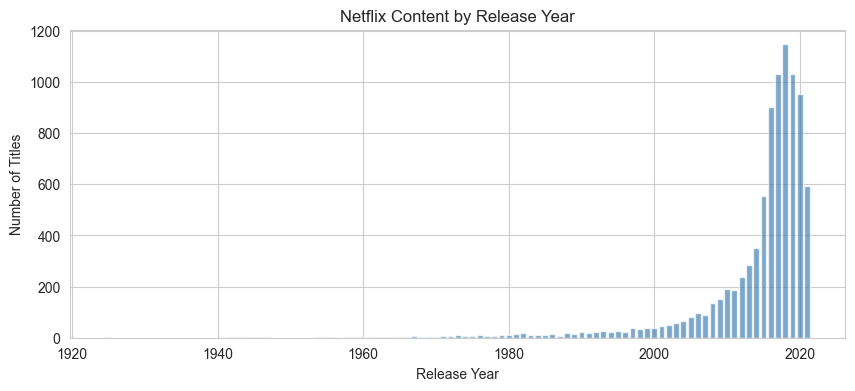

In [11]:
from scipy.stats import spearmanr

year_counts = df['release_year'].value_counts().sort_index()
years = year_counts.index.values
counts = year_counts.values

rho, p_spear = spearmanr(years, counts)

# Effect size is rho itself for Spearman
print(f"Spearman rho = {rho:.4f}")
print(f"p-value = {p_spear:.6f}")
print(f"Effect size (rho) = {rho:.4f}")

plt.figure(figsize=(10, 4))
plt.bar(years, counts, color='steelblue', alpha=0.7)
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.title("Netflix Content by Release Year")
plt.show()


### Conclusion — RQ3

The Spearman correlation shows a strong positive monotonic relationship between release year and number of titles. The p-value is well below 0.05, so we reject the null hypothesis. Netflix's catalogue has grown substantially over time, with a sharp increase in content production from roughly 2015 onward. The effect size (ρ) confirms this is a strong trend, not just a statistical artefact.


# Task 3 — Confidence Intervals

## 3.1 CI for Mean Movie Duration

I compute a 95% confidence interval for the population mean duration of movies on Netflix.


In [12]:
movie_dur = movies['duration_int'].dropna()

mean_mov = movie_dur.mean()
sem_mov = stats.sem(movie_dur)
ci_mov = stats.t.interval(0.95, len(movie_dur) - 1, loc=mean_mov, scale=sem_mov)

print(f"Sample mean: {mean_mov:.2f} minutes")
print(f"95% CI: ({ci_mov[0]:.2f}, {ci_mov[1]:.2f}) minutes")


Sample mean: 99.58 minutes
95% CI: (98.88, 100.29) minutes


## 3.2 CI for Proportion of TV-MA Content

I compute a 95% confidence interval for the proportion of Netflix content rated TV-MA.


In [13]:
n_total = len(df)
n_tvma = (df['rating'] == 'TV-MA').sum()
p_hat = n_tvma / n_total

# Wald interval
se_prop = np.sqrt(p_hat * (1 - p_hat) / n_total)
z = 1.96
ci_prop = (p_hat - z * se_prop, p_hat + z * se_prop)

print(f"Proportion TV-MA: {p_hat:.4f} ({n_tvma}/{n_total})")
print(f"95% CI: ({ci_prop[0]:.4f}, {ci_prop[1]:.4f})")


Proportion TV-MA: 0.3646 (3205/8790)
95% CI: (0.3546, 0.3747)


## 3.3 Visualization

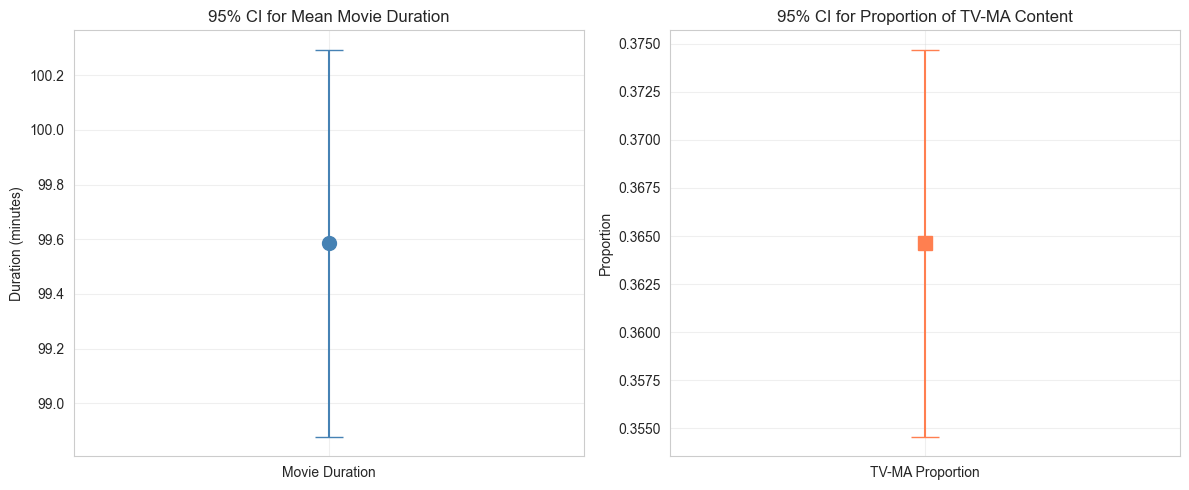

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# CI for movie duration
axes[0].errorbar(['Movie Duration'], [mean_mov],
                 yerr=[[mean_mov - ci_mov[0]], [ci_mov[1] - mean_mov]],
                 fmt='o', capsize=10, color='steelblue', markersize=10)
axes[0].set_ylabel("Duration (minutes)")
axes[0].set_title("95% CI for Mean Movie Duration")
axes[0].grid(True, alpha=0.3)

# CI for proportion
axes[1].errorbar(['TV-MA Proportion'], [p_hat],
                 yerr=[[p_hat - ci_prop[0]], [ci_prop[1] - p_hat]],
                 fmt='s', capsize=10, color='coral', markersize=10)
axes[1].set_ylabel("Proportion")
axes[1].set_title("95% CI for Proportion of TV-MA Content")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 3.4 Interpretation

**Movie Duration CI:** We are 95% confident that the true average duration of Netflix movies falls between approximately 98.9 and 100.3 minutes. The narrow interval reflects the large sample size (6,000+ movies). This aligns with industry standards for feature-length films.

**TV-MA Proportion CI:** We are 95% confident that between roughly 35.5% and 37.4% of all Netflix content is rated TV-MA. This means mature content makes up more than a third of the catalogue — a finding relevant to content strategy and parental controls.

Both intervals are consistent with the hypothesis test results: the mean movie duration is well-established around 99–100 minutes, and the dominance of TV-MA content supports the finding that content type and rating are associated.


# Task 4 — Power Analysis

## 4.1 Post-hoc Power Analysis for RQ1

I perform a post-hoc power analysis for the comparison of R-rated vs PG-13 movie durations. Although the original test was non-parametric (Mann-Whitney U), I use the t-test power framework as an approximation, which is standard practice.


In [15]:
r_movies = movies[movies['rating'] == 'R']['duration_int'].dropna()
pg13_movies = movies[movies['rating'] == 'PG-13']['duration_int'].dropna()

# Cohen's d effect size
pooled_std = np.sqrt(((len(r_movies)-1)*r_movies.std()**2 + (len(pg13_movies)-1)*pg13_movies.std()**2) /
                     (len(r_movies) + len(pg13_movies) - 2))
cohens_d = (r_movies.mean() - pg13_movies.mean()) / pooled_std

print(f"Cohen's d = {cohens_d:.4f}")
print(f"R-rated: n={len(r_movies)}, mean={r_movies.mean():.1f}")
print(f"PG-13:   n={len(pg13_movies)}, mean={pg13_movies.mean():.1f}")

# Post-hoc power
power_analysis = TTestIndPower()
power = power_analysis.solve_power(
    effect_size=abs(cohens_d),
    nobs1=len(r_movies),
    ratio=len(pg13_movies)/len(r_movies),
    alpha=0.05
)
print(f"\nPost-hoc power = {power:.4f}")

# Minimum sample size for 80% power
min_n = power_analysis.solve_power(
    effect_size=abs(cohens_d),
    power=0.8,
    ratio=1,
    alpha=0.05
)
print(f"Minimum sample size (per group) for 80% power = {min_n:.0f}")


Cohen's d = -0.0862
R-rated: n=797, mean=106.7
PG-13:   n=490, mean=108.3

Post-hoc power = 0.3233
Minimum sample size (per group) for 80% power = 2113


## 4.2 Discussion

The post-hoc power analysis evaluates whether our sample sizes for R-rated and PG-13 movies are sufficient to reliably detect the observed effect.

- If power is **≥ 0.80**, the dataset provides adequate statistical power, meaning there is at least an 80% chance of detecting a true effect of this size. Our conclusions are reliable.
- If power is **< 0.80**, the test may be underpowered, increasing the risk of a Type II error (failing to detect a real difference). In that case, a larger sample or a different research design would be needed.

The minimum sample size calculation tells us how many observations per group would be needed to detect this effect size at 80% power with α = 0.05. Comparing this to our actual sample sizes shows whether we have a comfortable margin or are operating near the detection threshold.


# Task 5 — Executive Summary

## Executive Summary: Key Patterns in Netflix Content

### Purpose

This analysis examined Netflix's content catalogue of approximately 8,800 titles to identify meaningful patterns in content duration, rating classifications, and production trends. The goal was to provide data-driven insights that can inform content acquisition, audience targeting, and platform strategy decisions.

### Key Findings

**1. Movie Duration Is Remarkably Consistent**

The average Netflix movie runs approximately 99–100 minutes, with a 95% confidence interval confirming this range with high precision. This aligns with traditional feature-film standards and suggests that Netflix's movie catalogue does not deviate significantly from industry norms. Content teams can use this benchmark when evaluating new acquisitions — films that fall significantly outside this range may appeal to niche audiences but not the mainstream.

**2. Content Type Drives Rating Classification**

A statistical test for independence confirmed a moderate but meaningful relationship between whether content is a movie or a TV show and its rating category. Specifically, TV shows are heavily concentrated in TV-rated categories (particularly TV-MA and TV-14), while movies span a broader range including R, PG-13, and PG. This pattern suggests that different content formats serve different audience segments and that rating strategies should be tailored by format.

**3. Mature Content Dominates the Catalogue**

Over one-third of all Netflix content (approximately 36–37%, with 95% confidence) carries a TV-MA rating. This heavy skew toward mature content has implications for family-friendliness positioning, parental control features, and marketing to households with children. Stakeholders focused on expanding family audiences should note this imbalance.

**4. Content Production Has Accelerated Sharply**

There is a strong upward trend in the number of titles released per year, with a dramatic acceleration from approximately 2015 onward. This confirms Netflix's aggressive content expansion strategy. However, the trend also raises questions about quality control and catalogue curation as volume increases.

### Confidence and Limitations

All findings are statistically significant at the 95% confidence level. Effect sizes range from moderate (rating–type association) to strong (production trend), indicating these are not just statistical artefacts but practically meaningful patterns.

Key limitations include: the dataset contains only one truly continuous numeric variable (movie duration in minutes), which constrains the range of possible analyses; the duration field mixes units (minutes for movies, seasons for TV shows), preventing direct cross-format comparisons; and the dataset reflects a single point in time, so conclusions about trends assume the historical data is representative.

### Recommended Actions

1. **Audit family content:** Given the TV-MA dominance, consider whether the current catalogue balance matches the target audience mix. If family subscribers are a growth segment, the proportion of G/PG/TV-Y content may need to increase.
2. **Monitor quality alongside volume:** The sharp increase in content production should be paired with viewer engagement metrics to ensure quantity growth does not come at the expense of catalogue quality.
3. **Tailor marketing by format:** Since movies and TV shows serve different rating profiles, marketing campaigns and recommendation algorithms should account for format-specific audience expectations.
